# YOLOv8s + CBAM + P2 

In [1]:
import warnings
warnings.filterwarnings("ignore")

!pip install ultralytics==8.3.148 -q

import ultralytics
print("Ultralytics version:", ultralytics.__version__)

from ultralytics import YOLO

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 15.4 MB/s eta 0:00:00a 0:00:01
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics version: 8.3.148


In [2]:
import os
import shutil
import random
from collections import Counter
from sklearn.model_selection import train_test_split

random.seed(42)

SOURCE_IMAGES = "/kaggle/input/datasets/makmudulhasanrabbi/road-surface-damage-datasetrsdd/data/images"
SOURCE_LABELS = "/kaggle/input/datasets/makmudulhasanrabbi/road-surface-damage-datasetrsdd/data/labels-YOLO"

OUTPUT_DATASET = "/kaggle/working/road_damage_dataset"

# --- SINGLE SOURCE OF TRUTH for class names (FIXED — was inconsistent / wrong order) ---
# NOTE: this must match the class ids actually used inside the label .txt files.
# Confirm against the dataset's own documentation/README if you are not 100% sure.
CLASS_NAMES = {
    0: "pothole",
    1: "crack",
    2: "manhole",
}

# CREATE FOLDERS
for split in ["train", "val", "test"]:
    os.makedirs(f"{OUTPUT_DATASET}/images/{split}", exist_ok=True)
    os.makedirs(f"{OUTPUT_DATASET}/labels/{split}", exist_ok=True)

# GET IMAGE FILES
image_files = [f for f in os.listdir(SOURCE_IMAGES) if f.endswith((".jpg", ".png", ".jpeg"))]
print(f"Total Images Found: {len(image_files)}")

# 70-15-15 SPLIT
train_files, temp_files = train_test_split(image_files, test_size=0.30, random_state=42)
val_files, test_files = train_test_split(temp_files, test_size=0.50, random_state=42)

print(f"Train: {len(train_files)}")
print(f"Val: {len(val_files)}")
print(f"Test: {len(test_files)}")

# COPY FILES
def copy_files(file_list, split):
    for file in file_list:
        image_src = os.path.join(SOURCE_IMAGES, file)
        label_src = os.path.join(SOURCE_LABELS, os.path.splitext(file)[0] + ".txt")

        image_dst = os.path.join(OUTPUT_DATASET, "images", split, file)
        label_dst = os.path.join(OUTPUT_DATASET, "labels", split, os.path.splitext(file)[0] + ".txt")

        shutil.copy(image_src, image_dst)
        if os.path.exists(label_src):
            shutil.copy(label_src, label_dst)

copy_files(train_files, "train")
copy_files(val_files, "val")
copy_files(test_files, "test")

print("Dataset Split Completed")

# --- NEW: per-class instance count diagnostic ---
# Tells you immediately whether "crack" is under-represented compared to the other
# classes. Heavy imbalance is the single most common reason a class under-performs,
# and no amount of hyperparameter tuning fully compensates for too few instances.
def count_instances(split):
    counter = Counter()
    labels_dir = os.path.join(OUTPUT_DATASET, "labels", split)
    for fname in os.listdir(labels_dir):
        if not fname.endswith(".txt"):
            continue
        with open(os.path.join(labels_dir, fname)) as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                cls_id = int(line.split()[0])
                counter[cls_id] += 1
    return counter

print("\nPer-class instance counts:")
print(f"{'class':10s}{'train':>10s}{'val':>10s}{'test':>10s}{'total':>10s}")
totals = Counter()
per_split = {s: count_instances(s) for s in ["train", "val", "test"]}
for cid, cname in CLASS_NAMES.items():
    row = [per_split[s][cid] for s in ["train", "val", "test"]]
    total = sum(row)
    totals[cid] = total
    marker = "  <-- crack" if cname == "crack" else ""
    print(f"{cname:10s}{row[0]:10d}{row[1]:10d}{row[2]:10d}{total:10d}{marker}")

Total Images Found: 2009
Train: 1406
Val: 301
Test: 302
Dataset Split Completed

Per-class instance counts:
class          train       val      test     total
pothole          903       185       173      1261
crack           1770       383       366      2519  <-- crack
manhole          654       147       156       957


In [3]:
import yaml

# DATA YAML
DATASET_ROOT = "/kaggle/working/road_damage_dataset"

# Reuses the single CLASS_NAMES defined above -- no more duplicate/inconsistent
# class-name dict floating around the notebook.
data_yaml = {
    "path": DATASET_ROOT,
    "train": "images/train",
    "val": "images/val",
    "test": "images/test",
    "names": CLASS_NAMES,
}

with open("data.yaml", "w") as f:
    yaml.dump(data_yaml, f)

print("data.yaml created successfully")
print(data_yaml)

data.yaml created successfully
{'path': '/kaggle/working/road_damage_dataset', 'train': 'images/train', 'val': 'images/val', 'test': 'images/test', 'names': {0: 'pothole', 1: 'crack', 2: 'manhole'}}


In [4]:
import torch
import torch.nn as nn

class ChannelAttention(nn.Module):
    def __init__(self, c1, ratio=16):
        super().__init__()
        hidden = max(c1 // ratio, 8)

        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)

        self.fc = nn.Sequential(
            nn.Conv2d(c1, hidden, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(hidden, c1, 1, bias=False),
        )

        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = self.fc(self.avg_pool(x))
        max_out = self.fc(self.max_pool(x))
        return self.sigmoid(avg_out + max_out)


class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size, padding=kernel_size // 2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        x = torch.cat([avg_out, max_out], dim=1)
        return self.sigmoid(self.conv(x))


class CBAM(nn.Module):
    def __init__(self, c1):
        super().__init__()
        self.ca = ChannelAttention(c1)
        self.sa = SpatialAttention()

    def forward(self, x):
        x = self.ca(x) * x
        x = self.sa(x) * x
        return x

In [5]:
p2_cbam_yaml = '''
nc: 3

scales:
  s: [0.33, 0.50, 1024]

backbone:
  - [-1, 1, Conv, [64, 3, 2]]
  - [-1, 1, Conv, [128, 3, 2]]
  - [-1, 3, C2f, [128, True]]

  - [-1, 1, Conv, [256, 3, 2]]
  - [-1, 6, C2f, [256, True]]

  - [-1, 1, Conv, [512, 3, 2]]
  - [-1, 6, C2f, [512, True]]

  - [-1, 1, Conv, [1024, 3, 2]]
  - [-1, 3, C2f, [1024, True]]

  - [-1, 1, SPPF, [1024, 5]]

head:

  # P5 -> P4
  - [-1, 1, nn.Upsample, [None, 2, "nearest"]]
  - [[-1, 6], 1, Concat, [1]]
  - [-1, 3, C2f, [512]]

  # P4 -> P3
  - [-1, 1, nn.Upsample, [None, 2, "nearest"]]
  - [[-1, 4], 1, Concat, [1]]
  - [-1, 3, C2f, [256]]

  # P3 -> P2 (highest-resolution feature map -- best for thin/small objects like cracks)
  - [-1, 1, nn.Upsample, [None, 2, "nearest"]]
  - [[-1, 2], 1, Concat, [1]]
  - [-1, 3, C2f, [128]]

  # CBAM on P2 -- channel + spatial attention right where thin crack features live
  - [-1, 1, CBAM, []]

  # P2 -> P3
  - [-1, 1, Conv, [128, 3, 2]]
  - [[-1, 15], 1, Concat, [1]]
  - [-1, 3, C2f, [256]]

  # P3 -> P4
  - [-1, 1, Conv, [256, 3, 2]]
  - [[-1, 12], 1, Concat, [1]]
  - [-1, 3, C2f, [512]]

  # P4 -> P5
  - [-1, 1, Conv, [512, 3, 2]]
  - [[-1, 9], 1, Concat, [1]]
  - [-1, 3, C2f, [1024]]

  # Detect (P2, P3, P4, P5 heads)
  - [[19, 22, 25, 28], 1, Detect, [nc]]
'''

with open("yolov8s_p2_cbam.yaml", "w") as f:
    f.write(p2_cbam_yaml)

print("YOLOv8s + P2 + CBAM YAML Saved")

YOLOv8s + P2 + CBAM YAML Saved


In [6]:
# FIXED: the old version permanently edited the *installed* ultralytics package
# file on disk (tasks.py) and never reloaded the module, so the patch could be
# silently inactive at runtime and would corrupt the installed package across runs.
#
# This version patches `parse_model` ONLY IN MEMORY, in the current process.
# No files are touched, and it is 100% reliable every run without a kernel restart,
# because `DetectionModel.__init__` looks up `parse_model` from the `tasks` module's
# own globals dict at call time -- reassigning `tasks.parse_model` is picked up
# immediately by every part of ultralytics that calls it.

import inspect
import ultralytics.nn.tasks as tasks
import ultralytics.nn.modules as modules

# Register CBAM class so `globals()['CBAM']` resolves inside tasks.py's namespace
tasks.CBAM = CBAM
modules.CBAM = CBAM

# Use a marker attribute rather than re-inspecting source each time: once
# parse_model has been rebuilt via exec() below it no longer has a real file
# backing it, so inspect.getsource() on it would raise OSError on a second run.
if not getattr(tasks.parse_model, "_cbam_patched", False):
    src = inspect.getsource(tasks.parse_model)
    target = "        elif m is Concat:\n            c2 = sum(ch[x] for x in f)\n"
    if target not in src:
        raise RuntimeError(
            "Could not find the expected 'elif m is Concat:' block in parse_model "
            "-- the installed ultralytics version may differ from 8.3.148."
        )

    cbam_block = (
        "        elif m is CBAM:\n"
        "            c1 = ch[f]\n"
        "            args = [c1, *args]\n"
        "            c2 = c1\n\n"
    )
    new_src = src.replace(target, cbam_block + target, 1)

    # Build the patched function in a namespace backed by tasks.__dict__ so it can
    # still see every other name parse_model normally relies on (Conv, C2f, ...).
    patched_ns = tasks.__dict__
    exec(compile(new_src, "<parse_model_with_cbam>", "exec"), patched_ns)
    new_parse_model = patched_ns["parse_model"]
    new_parse_model._cbam_patched = True
    tasks.parse_model = new_parse_model

    print("parse_model patched in memory (no installed files were modified)")
else:
    print("parse_model already patched")

parse_model patched in memory (no installed files were modified)


In [7]:
import yaml

# Verify the in-memory patch is actually the active function object
assert getattr(tasks.parse_model, "_cbam_patched", False), "CBAM patch not active!"
assert hasattr(tasks, "CBAM"), "CBAM not registered on tasks module!"
print("CBAM parser is active in memory ✅")

with open("yolov8s_p2_cbam.yaml") as f:
    cfg = yaml.safe_load(f)

print("\nCBAM layer(s) in architecture:")
for i, layer in enumerate(cfg["backbone"] + cfg["head"]):
    if "CBAM" in str(layer):
        print(i, layer)

model = YOLO("yolov8s_p2_cbam.yaml")
print("\nModel Built Successfully")

CBAM parser is active in memory ✅

CBAM layer(s) in architecture:
19 [-1, 1, 'CBAM', []]

Model Built Successfully


In [8]:
# Loads matching-shape pretrained COCO weights into the backbone (the custom P2+CBAM
# head layers won't have a matching pretrained counterpart and are left randomly
# initialized -- this is expected transfer-learning behaviour).
model = model.load("yolov8s.pt")
print("Pretrained backbone weights loaded")

100%|██████████| 21.5M/21.5M [00:00<00:00, 137MB/s]


Transferred 214/440 items from pretrained weights
Pretrained backbone weights loaded


In [ ]:
results = model.train(
    data="data.yaml",
    epochs=150,          # was 100 -- crack is the harder class, give it more room to converge
    imgsz=1024,
    batch=12,
    device=0,
    optimizer="AdamW",

    lr0=0.0007,          # was 0.0003 -- slightly higher so the harder class converges within budget
    lrf=0.01,
    weight_decay=0.0005,
    warmup_epochs=5,
    cos_lr=True,
    patience=50,         # was 40 -- matches the longer epoch budget
    pretrained=True,

    box=8.5,             # was default 7.5 -- tighter localization for thin/elongated boxes
    cls=0.5,
    dfl=1.5,

    mosaic=0.5,          # was 0.7 -- mosaic tiling often slices thin cracks in half
    close_mosaic=20,     # was 15 -- more clean, un-mosaiced epochs at the end to settle fine detail
    mixup=0.0,           # was 0.05 -- blending images washes out low-contrast crack edges
    copy_paste=0.15,     # new -- boosts instance density, helps an under-represented class
    erasing=0.10,        # was 0.20 -- less risk of erasing an entire thin crack region

    degrees=3.0,
    translate=0.2,
    scale=0.4,           # was 0.6 -- less aggressive zoom jitter preserves thin crack shape
    shear=0.0,
    perspective=0.0,

    fliplr=0.5,
    flipud=0.0,

    hsv_h=0.015,
    hsv_s=0.5,
    hsv_v=0.3,

    cache=True,
    amp=True,
    deterministic=False,
    seed=42,
    plots=True,          # new -- saves per-class PR/F1 curves automatically

    project="RoadDamage",
    name="YOLOv8s_P2_CBAM",
)

New https://pypi.org/project/ultralytics/8.4.127 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.148 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=12, bgr=0.0, box=8.5, cache=True, cfg=None, classes=None, close_mosaic=20, cls=0.5, conf=None, copy_paste=0.15, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=data.yaml, degrees=3.0, deterministic=False, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=150, erasing=0.1, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.5, hsv_v=0.3, imgsz=1024, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0007, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s_p2_cbam.yaml, momentum=0.937, mosaic=0.5, multi_scale=False, name=YOLOv8s_P2_CBAM, nbs=64, nms=False, opset=None, optimize=F

100%|██████████| 755k/755k [00:00<00:00, 16.6MB/s]



                   from  n    params  module                                       arguments                     
  0                  -1  1       928  ultralytics.nn.modules.conv.Conv             [3, 32, 3, 2]                 
  1                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  2                  -1  1     29056  ultralytics.nn.modules.block.C2f             [64, 64, 1, True]             
  3                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  4                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  5                  -1  1    295424  ultralytics.nn.modules.conv.Conv             [128, 256, 3, 2]              
  6                  -1  2    788480  ultralytics.nn.modules.block.C2f             [256, 256, 2, True]           
  7                  -1  1   1180672  ultralytics.nn.modules.conv.Conv             [256

100%|██████████| 5.35M/5.35M [00:00<00:00, 69.9MB/s]


AMP: checks passed ✅
train: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1965.7±486.7 MB/s, size: 98.0 KB)


...


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


     89/150      10.5G      1.209     0.7523      1.534          8       1024: 100%|██████████| 118/118 [01:33<00:00,  1.27it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 13/13 [00:05<00:00,  2.54it/s]

                   all        301        715      0.578      0.552      0.544      0.233



      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


     90/150      10.2G      1.219     0.7638      1.547          4       1024: 100%|██████████| 118/118 [01:32<00:00,  1.28it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95):  85%|████████▍ | 11/13 [00:04<00:00,  2.44it/s]

In [23]:
metrics = model.val(data="data.yaml", plots=True)

print("Overall (mean over all classes)")
print(f"  Precision : {metrics.box.mp:.4f}")
print(f"  Recall    : {metrics.box.mr:.4f}")
print(f"  mAP50     : {metrics.box.map50:.4f}")
print(f"  mAP50-95  : {metrics.box.map:.4f}")

# FIXED: `metrics.box.p` / `metrics.box.r` / `metrics.box.ap50` / `metrics.box.ap`
# are ordered by `ap_class_index`, NOT by raw class id -- indexing them directly
# with the class id (as the original notebook did for maps()) can silently report
# the wrong class's numbers. `metrics.box.maps` IS already remapped to class-id
# order internally, but p/r/ap50 are not, so we map them by hand here.
print("\nPer-class metrics")
print(f"{'class':10s}{'P':>10s}{'R':>10s}{'mAP50':>10s}{'mAP50-95':>10s}")
for i, cid in enumerate(metrics.box.ap_class_index):
    name = metrics.names[cid]
    p = metrics.box.p[i]
    r = metrics.box.r[i]
    ap50 = metrics.box.ap50[i]
    ap = metrics.box.ap[i]
    marker = "  <-- crack" if name == "crack" else ""
    print(f"{name:10s}{p:10.4f}{r:10.4f}{ap50:10.4f}{ap:10.4f}{marker}")

Ultralytics 8.3.148 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2493.9±528.6 MB/s, size: 89.2 KB)


val: Scanning /kaggle/working/road_damage_dataset/labels/val.cache... 301 images, 0 backgrounds, 0 corrupt: 100%|██████████| 301/301 [00:00<?, ?it/s]
val: Caching images (0.5GB RAM): 100%|██████████| 301/301 [00:00<00:00, 477.19it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 26/26 [00:09<00:00,  2.67it/s]


                   all        301        715      0.618      0.534      0.559      0.257
               pothole        115        185      0.588      0.432      0.488       0.21
                 crack        205        383      0.516      0.409      0.406      0.146
               manhole        117        147      0.751      0.762      0.782      0.416
Speed: 1.2ms preprocess, 25.9ms inference, 0.0ms loss, 0.9ms postprocess per image
Results saved to RoadDamage/YOLOv8s_P2_CBAM4
Overall (mean over all classes)
  Precision : 0.6180
  Recall    : 0.5345
  mAP50     : 0.5586
  mAP50-95  : 0.2572

Per-class metrics
class              P         R     mAP50  mAP50-95
pothole       0.5876    0.4324    0.4881    0.2105
crack         0.5160    0.4092    0.4055    0.1457  <-- crack
manhole       0.7506    0.7619    0.7823    0.4156


In [24]:
results = model.predict(
    source=os.path.join(DATASET_ROOT, "images/test"),
    save=True,
    conf=0.25,
)
print("Prediction Completed")


image 1/302 /kaggle/working/road_damage_dataset/images/test/20250219_164838.jpg: 576x1024 1 crack, 1 manhole, 32.3ms
image 2/302 /kaggle/working/road_damage_dataset/images/test/20250219_165042.jpg: 576x1024 2 potholes, 1 crack, 31.2ms
image 3/302 /kaggle/working/road_damage_dataset/images/test/20250219_165100.jpg: 576x1024 2 potholes, 31.2ms
image 4/302 /kaggle/working/road_damage_dataset/images/test/20250219_165339.jpg: 576x1024 1 pothole, 31.2ms
image 5/302 /kaggle/working/road_damage_dataset/images/test/20250219_165709.jpg: 576x1024 1 pothole, 31.3ms
image 6/302 /kaggle/working/road_damage_dataset/images/test/20250219_170531.jpg: 576x1024 2 potholes, 20.8ms
image 7/302 /kaggle/working/road_damage_dataset/images/test/20250219_170838.jpg: 576x1024 2 potholes, 20.9ms
image 8/302 /kaggle/working/road_damage_dataset/images/test/20250219_170909.jpg: 576x1024 (no detections), 20.9ms
image 9/302 /kaggle/working/road_damage_dataset/images/test/20250223_143954.jpg: 576x1024 2 cracks, 20.4ms


In [25]:
import pandas as pd
import matplotlib.pyplot as plt

results_csv = "/kaggle/working/RoadDamage/YOLOv8s_P2_CBAM/results.csv"
df = pd.read_csv(results_csv)
df.columns = df.columns.str.strip()
df.head()

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
0,1,93.4886,3.39277,3.86509,3.36797,0.02167,0.04787,0.01664,0.00486,3.31567,5.39356,3.15206,0.080308,0.000139,0.000139
1,2,193.5750,2.97179,2.88458,3.03202,0.26337,0.24240,0.19360,0.06419,2.98259,2.99000,3.05001,0.060448,0.000279,0.000279
2,3,293.2570,2.72838,2.73905,2.86520,0.25113,0.38971,0.28294,0.09869,2.61046,2.98505,2.81848,0.040588,0.000419,0.000419
3,4,392.0310,2.56850,2.61152,2.73747,0.28378,0.34843,0.26856,0.10237,2.62013,2.58224,2.78701,0.020728,0.000558,0.000558
4,5,491.0550,2.47503,2.55682,2.67617,0.37681,0.39201,0.35053,0.14460,2.48427,2.51861,2.66444,0.000867,0.000698,0.000698


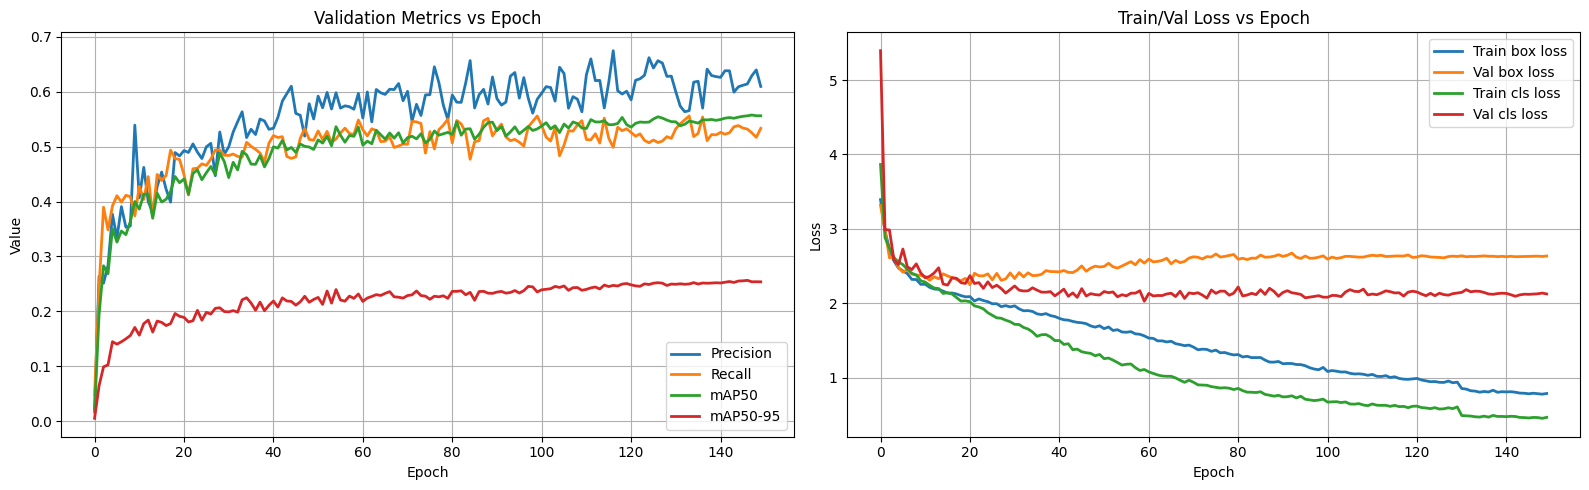

In [26]:
# FIXED: the old plot mislabeled precision/mAP50 as "Train/Validation Accuracy"
# (they're validation-set precision and mAP, not "accuracy"), and mixed loss values
# (0-5 range) with metric values (0-1 range) on the same axis, making both hard to read.
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(df["metrics/precision(B)"], label="Precision", linewidth=2)
axes[0].plot(df["metrics/recall(B)"], label="Recall", linewidth=2)
axes[0].plot(df["metrics/mAP50(B)"], label="mAP50", linewidth=2)
axes[0].plot(df["metrics/mAP50-95(B)"], label="mAP50-95", linewidth=2)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Value")
axes[0].set_title("Validation Metrics vs Epoch")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(df["train/box_loss"], label="Train box loss", linewidth=2)
axes[1].plot(df["val/box_loss"], label="Val box loss", linewidth=2)
axes[1].plot(df["train/cls_loss"], label="Train cls loss", linewidth=2)
axes[1].plot(df["val/cls_loss"], label="Val cls loss", linewidth=2)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].set_title("Train/Val Loss vs Epoch")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

Total Images Found: 21


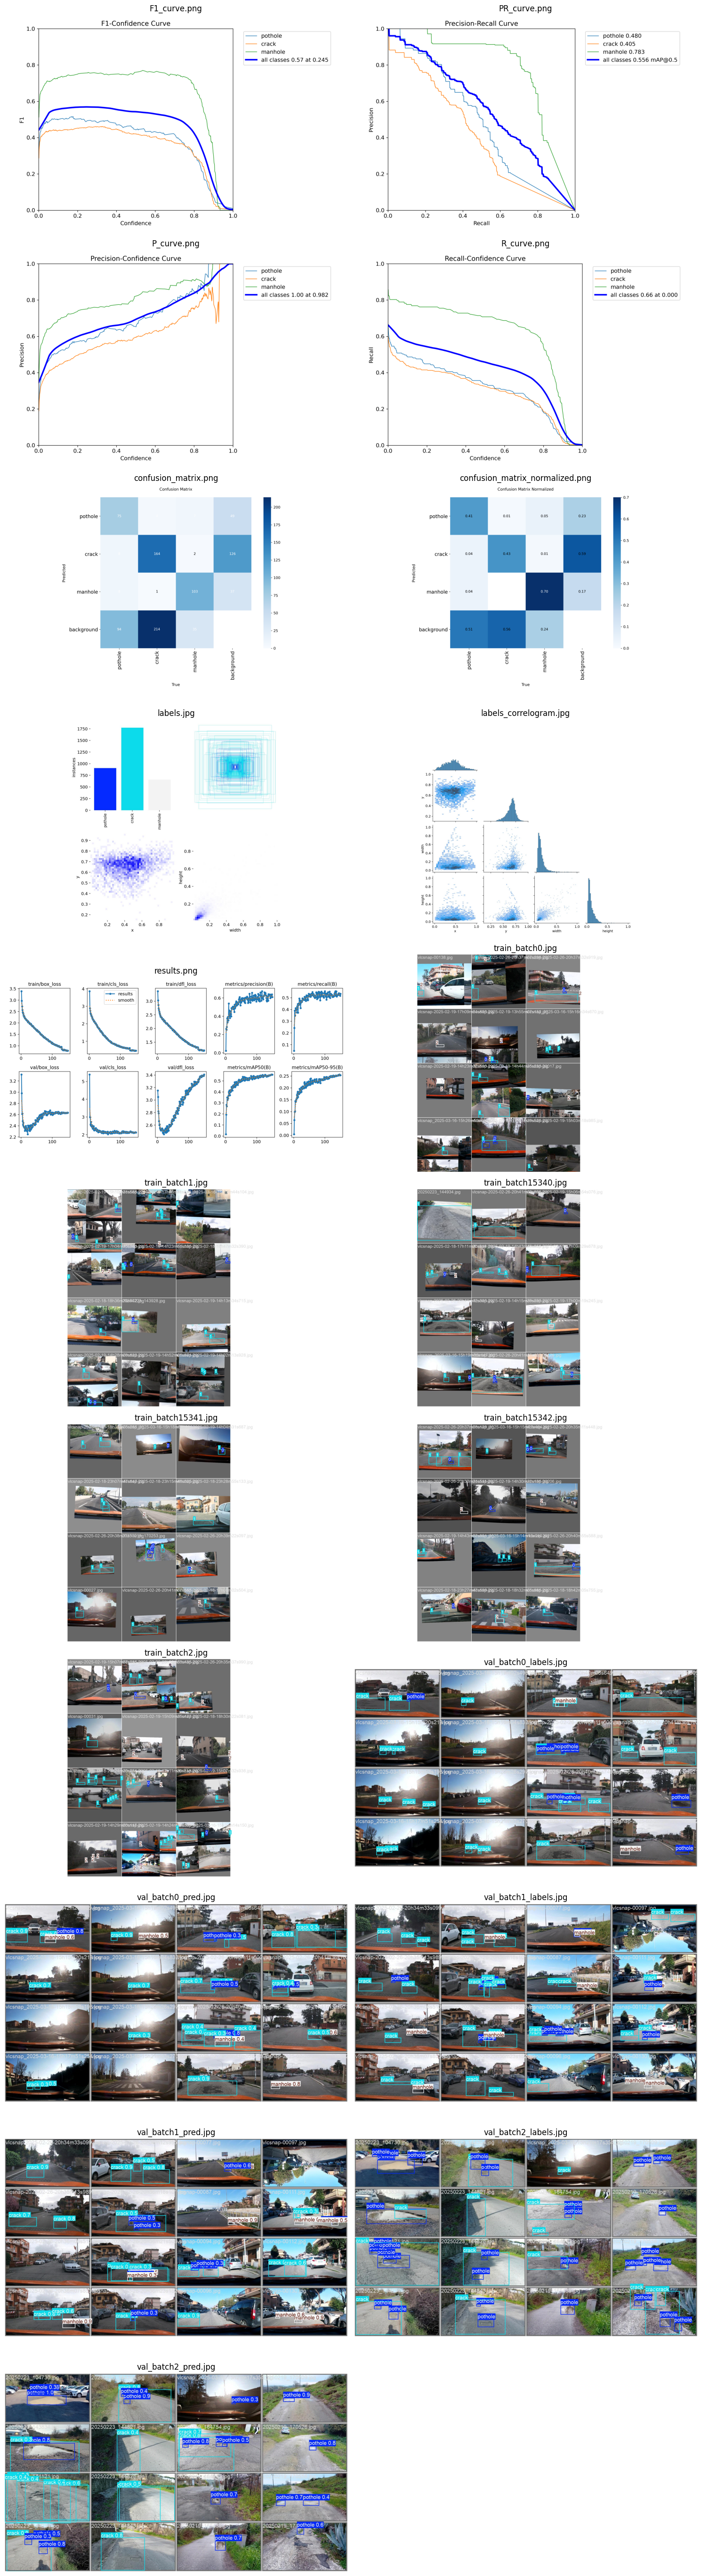

In [27]:
import os
import math
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

folder_path = "/kaggle/working/RoadDamage/YOLOv8s_P2_CBAM"

image_files = sorted(
    f for f in os.listdir(folder_path) if f.lower().endswith((".png", ".jpg", ".jpeg"))
)
print("Total Images Found:", len(image_files))

cols = 2
rows = math.ceil(len(image_files) / cols) if image_files else 0

if rows:
    plt.figure(figsize=(15, rows * 5))
    for idx, image_name in enumerate(image_files):
        img = mpimg.imread(os.path.join(folder_path, image_name))
        plt.subplot(rows, cols, idx + 1)
        plt.imshow(img)
        plt.title(image_name)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

Using image: /kaggle/working/road_damage_dataset/images/test/20250219_165042.jpg
Figure saved to: /kaggle/working/detection_guided_activation_map.png


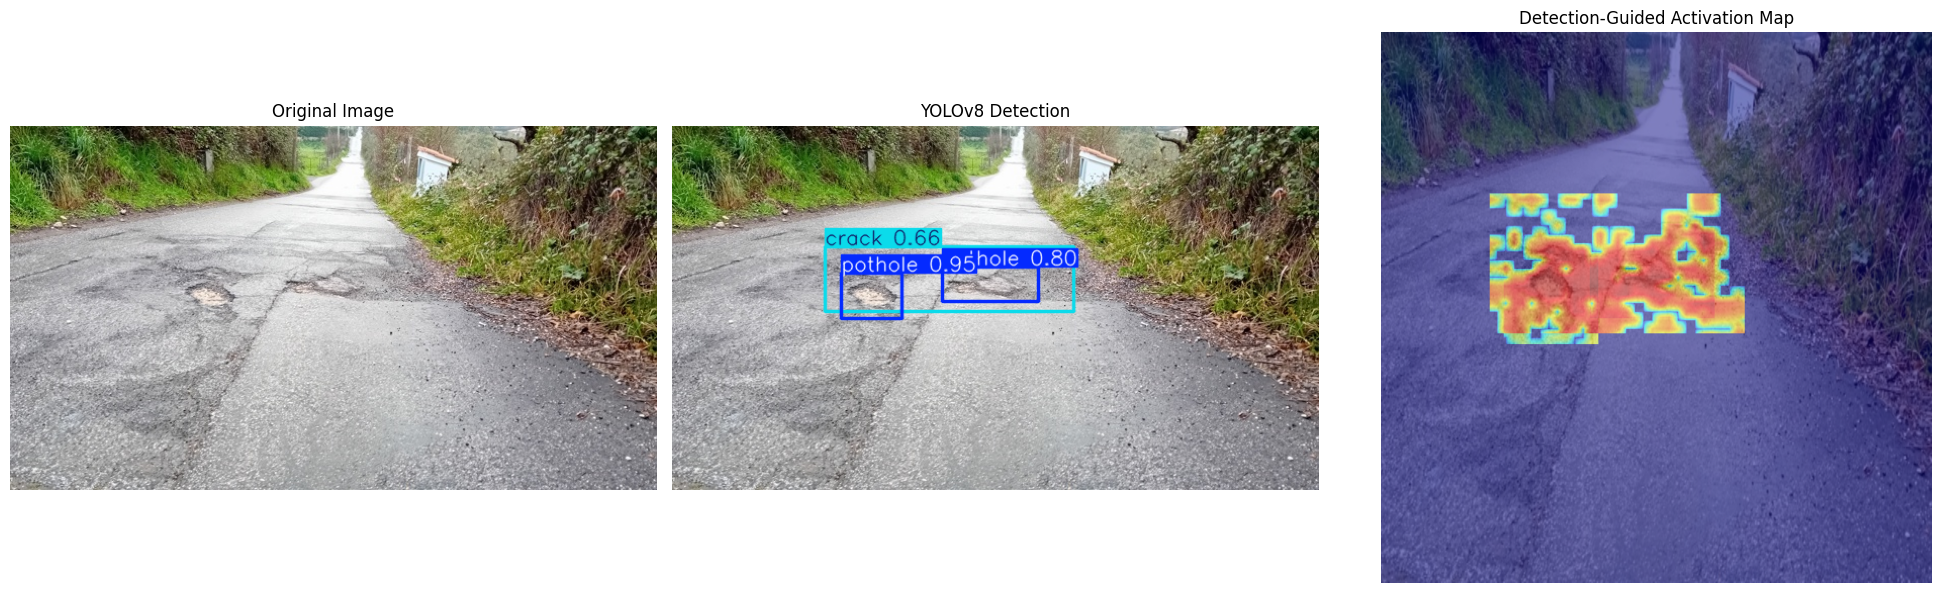

In [28]:
!pip install -q grad-cam

import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO

# Load model
gradcam_model = YOLO("/kaggle/working/RoadDamage/YOLOv8s_P2_CBAM/weights/best.pt")
yolo_model = gradcam_model.model.eval()

# FIXED: the original hardcoded a specific filename that may not exist in this
# run's random test split. Pick the first available test image dynamically instead.
test_dir = os.path.join(DATASET_ROOT, "images/test")
test_images = sorted(
    f for f in os.listdir(test_dir) if f.lower().endswith((".jpg", ".jpeg", ".png"))
)
assert test_images, "No test images found -- check DATASET_ROOT / split."
IMAGE_PATH = os.path.join(test_dir, test_images[1])
print("Using image:", IMAGE_PATH)

IMG_SIZE = 1024
TARGET_LAYER = 12

feature_maps = []

def hook_fn(module, input, output):
    feature_maps.append(output)

handle = yolo_model.model[TARGET_LAYER].register_forward_hook(hook_fn)

img = cv2.imread(IMAGE_PATH)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
h0, w0 = img.shape[:2]

img_resized = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
rgb_img = img_resized.astype(np.float32) / 255.0

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
input_tensor = torch.from_numpy(rgb_img.transpose(2, 0, 1)).unsqueeze(0).float().to(device)
yolo_model = yolo_model.to(device)

feature_maps.clear()
with torch.no_grad():
    _ = yolo_model(input_tensor)

activation = feature_maps[0]
heatmap = activation[0].mean(dim=0).cpu().numpy()
heatmap = np.maximum(heatmap, 0)
heatmap = heatmap / (heatmap.max() + 1e-8)

p_low = np.percentile(heatmap, 65)
p_high = np.percentile(heatmap, 99)
heatmap = np.clip((heatmap - p_low) / (p_high - p_low + 1e-8), 0, 1)

gamma = 0.4
heatmap = np.power(heatmap, gamma)
heatmap[heatmap < 0.30] = 0
heatmap = cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE))

results = gradcam_model.predict(source=IMAGE_PATH, conf=0.25, verbose=False)
det_img = results[0].plot()

guided_heatmap = np.zeros_like(heatmap)
boxes = results[0].boxes.xyxy.cpu().numpy()
classes = results[0].boxes.cls.cpu().numpy()

sx = IMG_SIZE / w0
sy = IMG_SIZE / h0

# class ids now correctly follow CLASS_NAMES = {0: pothole, 1: crack, 2: manhole}
# crack (1) and manhole (2) get extra visual weight; tweak CRACK_WEIGHT to taste.
CRACK_WEIGHT = 3.0
MANHOLE_WEIGHT = 2.0
POTHOLE_WEIGHT = 1.0

for box, cls_id in zip(boxes, classes):
    x1, y1, x2, y2 = box
    x1, x2 = int(x1 * sx), int(x2 * sx)
    y1, y2 = int(y1 * sy), int(y2 * sy)

    pad = 40
    x1, y1 = max(0, x1 - pad), max(0, y1 - pad)
    x2, y2 = min(IMG_SIZE, x2 + pad), min(IMG_SIZE, y2 + pad)

    cls_id = int(cls_id)
    weight = {0: POTHOLE_WEIGHT, 1: CRACK_WEIGHT, 2: MANHOLE_WEIGHT}.get(cls_id, 1.0)

    guided_heatmap[y1:y2, x1:x2] += weight * heatmap[y1:y2, x1:x2]

guided_heatmap = guided_heatmap / (guided_heatmap.max() + 1e-8)
guided_heatmap = np.power(guided_heatmap, 0.30)
guided_heatmap[guided_heatmap < 0.15] = 0

guided_heatmap_color = cv2.applyColorMap(np.uint8(255 * guided_heatmap), cv2.COLORMAP_JET)
guided_heatmap_color = cv2.cvtColor(guided_heatmap_color, cv2.COLOR_BGR2RGB)

guided_overlay = cv2.addWeighted(
    np.uint8(rgb_img * 255), 0.50, guided_heatmap_color, 0.50, 0
)

plt.figure(figsize=(20, 6))

plt.subplot(1, 3, 1)
plt.imshow(img)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(det_img[:, :, ::-1])
plt.title("YOLOv8 Detection")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(guided_overlay)
plt.title("Detection-Guided Activation Map")
plt.axis("off")

plt.tight_layout()

save_path = "/kaggle/working/detection_guided_activation_map.png"
plt.savefig(save_path, dpi=600, bbox_inches="tight", pad_inches=0.1)
print(f"Figure saved to: {save_path}")

plt.show()
handle.remove()

Ultralytics 8.3.148 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLOv8s_p2_cbam summary (fused): 98 layers, 10,628,350 parameters, 0 gradients, 36.6 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2073.5±789.8 MB/s, size: 96.5 KB)


val: Scanning /kaggle/working/road_damage_dataset/labels/val.cache... 301 images, 0 backgrounds, 0 corrupt: 100%|██████████| 301/301 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 19/19 [00:09<00:00,  2.01it/s]


                   all        301        715      0.618      0.534      0.559      0.257
               pothole        115        185      0.588      0.432      0.488       0.21
                 crack        205        383      0.516      0.409      0.406      0.146
               manhole        117        147      0.751      0.762      0.782      0.416
Speed: 1.6ms preprocess, 23.8ms inference, 0.0ms loss, 0.9ms postprocess per image
Results saved to runs/detect/val2

Per-Class Metrics
class              P         R     mAP50  mAP50-95
pothole       0.5876    0.4324    0.4881    0.2105
crack         0.5160    0.4092    0.4055    0.1457  <-- crack
manhole       0.7506    0.7619    0.7823    0.4156


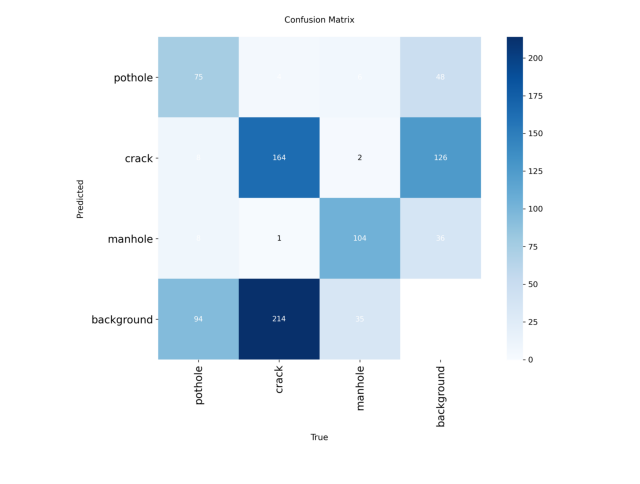


Precision (mean)  : 0.6180
Recall (mean)     : 0.5345
F1 Score (mean)   : 0.5732
mAP@0.5           : 0.5586
mAP@0.5:0.95      : 0.2572
FPS               : 39.99
Latency           : 25.01 ms
Total Parameters  : 10,628,350
Trainable Params  : 0
YOLOv8s_p2_cbam summary (fused): 98 layers, 10,628,350 parameters, 0 gradients, 36.6 GFLOPs


(98, 10628350, 0, 36.6390784)

In [29]:
from ultralytics import YOLO
from ultralytics.utils.torch_utils import model_info
from PIL import Image
import matplotlib.pyplot as plt
import cv2
import time
import os

best_model = "/kaggle/working/RoadDamage/YOLOv8s_P2_CBAM/weights/best.pt"
final_model = YOLO(best_model)

results = final_model.val(data="data.yaml", plots=True)

precision = results.box.mp
recall = results.box.mr
map50 = results.box.map50
map5095 = results.box.map
f1 = 2 * precision * recall / (precision + recall + 1e-16)

# FIXED: correctly aligned per-class P/R/mAP50/mAP50-95 (see note in the val cell above)
print("\nPer-Class Metrics")
print(f"{'class':10s}{'P':>10s}{'R':>10s}{'mAP50':>10s}{'mAP50-95':>10s}")
for i, cid in enumerate(results.box.ap_class_index):
    name = final_model.names[cid]
    marker = "  <-- crack" if name == "crack" else ""
    print(
        f"{name:10s}{results.box.p[i]:10.4f}{results.box.r[i]:10.4f}"
        f"{results.box.ap50[i]:10.4f}{results.box.ap[i]:10.4f}{marker}"
    )

total_params = sum(p.numel() for p in final_model.model.parameters())
trainable_params = sum(p.numel() for p in final_model.model.parameters() if p.requires_grad)

# FIXED: dynamic image pick instead of a hardcoded filename that may not exist
val_dir = os.path.join(DATASET_ROOT, "images/val")
val_images = sorted(f for f in os.listdir(val_dir) if f.lower().endswith((".jpg", ".jpeg", ".png")))
image_path = os.path.join(val_dir, val_images[0])
image = cv2.imread(image_path)

for _ in range(20):
    final_model.predict(image, verbose=False)

runs = 100
start = time.time()
for _ in range(runs):
    final_model.predict(image, verbose=False)
end = time.time()

fps = runs / (end - start)
latency = 1000 / fps

cm_path = os.path.join(results.save_dir, "confusion_matrix.png")
if os.path.exists(cm_path):
    plt.figure(figsize=(8, 8))
    plt.imshow(Image.open(cm_path))
    plt.axis("off")
    plt.show()

print(f"\nPrecision (mean)  : {precision:.4f}")
print(f"Recall (mean)     : {recall:.4f}")
print(f"F1 Score (mean)   : {f1:.4f}")
print(f"mAP@0.5           : {map50:.4f}")
print(f"mAP@0.5:0.95      : {map5095:.4f}")
print(f"FPS               : {fps:.2f}")
print(f"Latency           : {latency:.2f} ms")
print(f"Total Parameters  : {total_params:,}")
print(f"Trainable Params  : {trainable_params:,}")

model_info(final_model.model)

In [ ]:
import os
import zipfile

base = "/kaggle/working"

items = [
    "RoadDamage",
    "runs",
    "yolov8s_p2_cbam.yaml",
    "data.yaml",
    "yolov8s.pt",
    "detection_guided_activation_map.png",
]

zip_path = "/kaggle/working/yolov8s_cbam_p2_outputs.zip"
print("Creating ZIP...")
print("Destination:", zip_path)

with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED, compresslevel=6) as z:
    for item in items:
        path = os.path.join(base, item)
        if not os.path.exists(path):
            print("SKIP - not found:", item)
            continue
        if os.path.isfile(path):
            z.write(path, arcname=item)
            print("Added:", item)
        elif os.path.isdir(path):
            for root, dirs, files in os.walk(path):
                for file in files:
                    full_path = os.path.join(root, file)
                    arcname = os.path.relpath(full_path, base)
                    z.write(full_path, arcname=arcname)
            print("Added folder:", item)

print("\nZIP CREATED SUCCESSFULLY!")
size = os.path.getsize(zip_path) / (1024 ** 3)
print(f"ZIP size: {size:.3f} GB")
print("Path:", zip_path)